# Prediction et optimisation

In [135]:
import pandas as pd
import numpy as np
import seaborn as sns

from sklearn.model_selection import (
    GridSearchCV,
)

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

from sklearn import set_config
from sklearn.svm import SVR

from sklearn.metrics import mean_absolute_error, root_mean_squared_error, make_scorer
from sklearn.model_selection import train_test_split, cross_validate
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline

from sklearn.linear_model import (
    LinearRegression,
    Lasso
)

# Active le mode "Pandas" pour toutes les transformations scikit-learn
set_config(transform_output="pandas")
pd.set_option('display.max_rows', 500)
pd.set_option('display.max_columns', 500)
pd.set_option('display.width', 1000)

In [136]:
data = pd.read_csv('data/processed/data.csv', sep=',', na_values=[''], quotechar='"')

## Encodage et séparation train / test

In [137]:
labels_consumption = data['SiteEnergyUse(kBtu)']
labels_emissions = data['TotalGHGEmissions']
data = data.drop(columns=['SiteEnergyUse(kBtu)', 'TotalGHGEmissions'])

In [138]:
X_train, X_test, y_train, y_test = train_test_split(data, labels_emissions, test_size=0.2, random_state=42)
data_train_emissions = {
    'X_train' : X_train,
    'X_test' : X_test,
    'y_train' : y_train,
    'y_test' : y_test,
}

In [139]:
X_train, X_test, y_train, y_test = train_test_split(data, labels_consumption, test_size=0.2, random_state=42)
data_train_consumption = {
    'X_train' : X_train,
    'X_test' : X_test,
    'y_train' : y_train,
    'y_test' : y_test,
}

In [140]:
# Création d'un résumé rapide des colonnes restantes et leur nombre de valeurs uniques
summary = pd.DataFrame({
    'Colonnes': data.columns,
    'Valeurs uniques': data.nunique().values
})

summary = summary.sort_values(by='Valeurs uniques', ascending=False)

print(summary)

                  Colonnes  Valeurs uniques
16   supericie_by_building             1543
17  superficie_by_activity             1536
8         PropertyGFATotal             1513
10  PropertyGFABuilding(s)             1508
4                 Latitude             1431
5                Longitude             1348
14      ratio_dominant_use             1042
13          ratio_building              315
12           ratio_parking              315
9       PropertyGFAParking              311
15            building_age              113
7           NumberofFloors               44
1      PrimaryPropertyType               21
3             Neighborhood               19
6        NumberofBuildings               15
11    number_of_activities               10
2      CouncilDistrictCode                7
0             BuildingType                5


In [141]:
# Encodage one Hot des colonnes catégorielles avec peu de catégories
columns_to_encode = ['CouncilDistrictCode', 'BuildingType', 'PrimaryPropertyType', 'Neighborhood']

preprocessor = ColumnTransformer(
    transformers=[
        ('encoder', OneHotEncoder(handle_unknown='infrequent_if_exist', sparse_output=False), columns_to_encode),
    ],
    remainder='passthrough'
)

## Prédiction

In [142]:
# Fonction pour entrainer notre modèle et évaluer ses performances
def test_model(pipeline, d):

    scoring = {'r2': 'r2', 'rmse': 'neg_root_mean_squared_error'}

    cv_results = cross_validate(
        pipeline,
        d['X_train'],
        d['y_train'],
        cv=5,
        scoring=scoring,
    )

    # sklearn retourne le RMSE en négatif donc multiplier par -1 pour avoir la valeur correcte
    r2_scores = cv_results['test_r2']
    rmse_scores = -cv_results['test_rmse']

    print(f"Scores R² par fold : {r2_scores}")
    print(f"Score moyen (R²) : {r2_scores.mean():.3f} (+/- {r2_scores.std() * 2:.3f})")
    print(f"RMSE moyen (CV) : {rmse_scores.mean():.0f}")

    pipeline.fit(d['X_train'], d['y_train'])

    y_pred_log = pipeline.predict(d['X_test'])

    mae = mean_absolute_error(np.expm1(d['y_test']), np.expm1(y_pred_log))
    rmse = root_mean_squared_error(np.expm1(d['y_test']), np.expm1(y_pred_log))

    print(f"En moyenne, le modèle se trompe de : {mae:,.0f} (MAE)")
    print(f"Pénalité des grosses erreurs : {rmse:,.0f} (RMSE)")

    residuals = d['y_test'] - y_pred_log

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    axes[0].scatter(y_pred_log, d['y_test'], alpha=0.3)
    axes[0].plot([d['y_test'].min(), d['y_test'].max()], [d['y_test'].min(), d['y_test'].max()], 'r--')
    axes[0].set_title('Prédiction vs Réalité')

    axes[1].hist(residuals, bins=50)
    axes[1].set_title('Distribution des écarts')

### LinearRegression

Scores R² par fold : [0.62739793 0.69763964 0.60522561 0.6344088  0.72063007]
Score moyen (R²) : 0.657 (+/- 0.088)
RMSE moyen (CV) : 1
En moyenne, le modèle se trompe de : 3,461,718 (MAE)
Pénalité des grosses erreurs : 7,256,550 (RMSE)


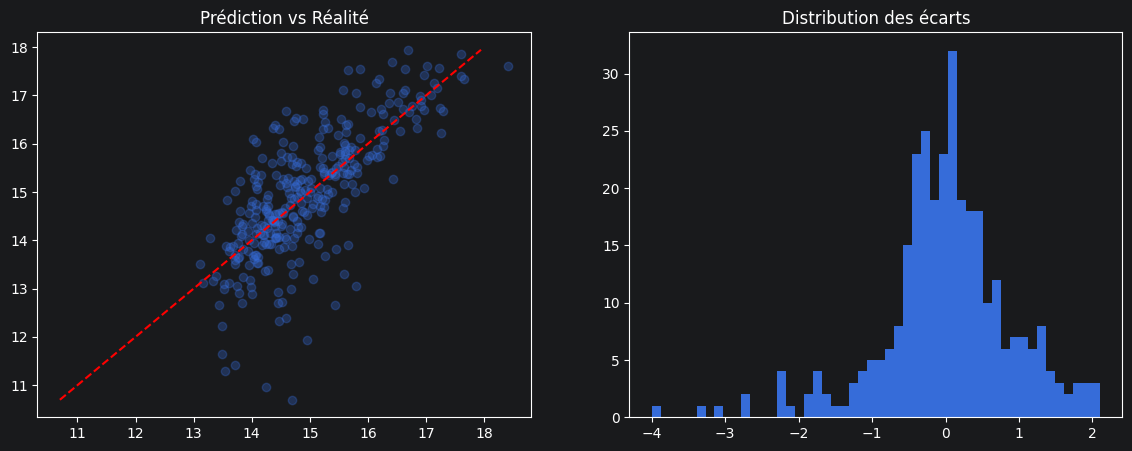

In [143]:
model_linear_regression = LinearRegression()
pipeline_linear_regression_consumption = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', model_linear_regression)
])
test_model(pipeline_linear_regression_consumption, data_train_consumption)

### RandomForest

Scores R² par fold : [0.65399607 0.72219087 0.66324169 0.65830912 0.74870405]
Score moyen (R²) : 0.689 (+/- 0.077)
RMSE moyen (CV) : 1
En moyenne, le modèle se trompe de : 3,219,914 (MAE)
Pénalité des grosses erreurs : 6,609,262 (RMSE)


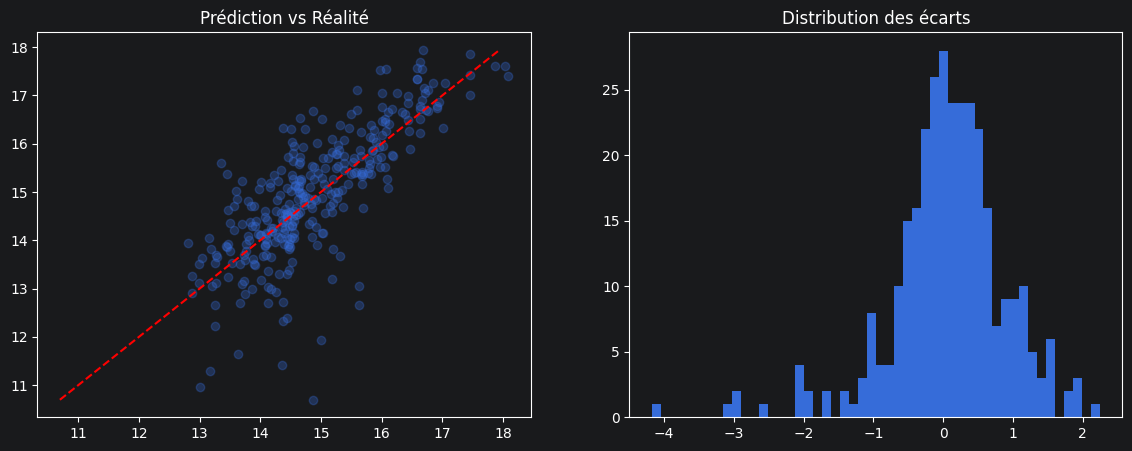

In [144]:
# Entrainement et performance du modèle de prédiction de la consommation
model_forest_consumption = RandomForestRegressor(random_state=42, n_jobs=-1)
pipeline_forest_consumption = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', model_forest_consumption)
])
test_model(pipeline_forest_consumption, data_train_consumption)

Scores R² par fold : [0.71706226 0.74523837 0.69819802 0.68634993 0.75348797]
Score moyen (R²) : 0.720 (+/- 0.052)
RMSE moyen (CV) : 1
En moyenne, le modèle se trompe de : 2,912,722 (MAE)
Pénalité des grosses erreurs : 5,857,380 (RMSE)


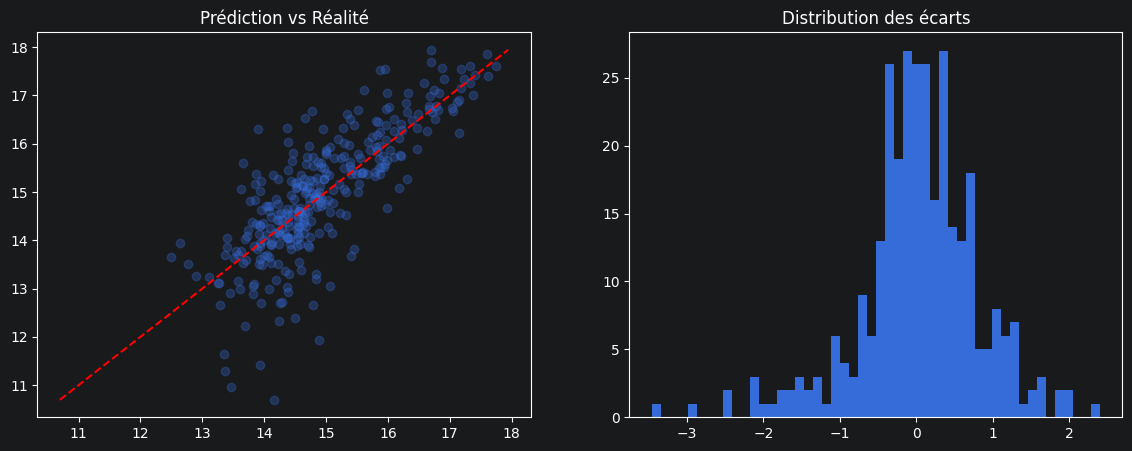

In [145]:
model_xgboost = GradientBoostingRegressor(random_state=42)
pipeline_xgboost_consumption = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', model_xgboost)
])
test_model(pipeline_xgboost_consumption, data_train_consumption)

### Lasso

Scores R² par fold : [0.40259215 0.45972803 0.25683226 0.43020297 0.43373438]
Score moyen (R²) : 0.397 (+/- 0.144)
RMSE moyen (CV) : 1
En moyenne, le modèle se trompe de : 5,063,024 (MAE)
Pénalité des grosses erreurs : 12,441,991 (RMSE)


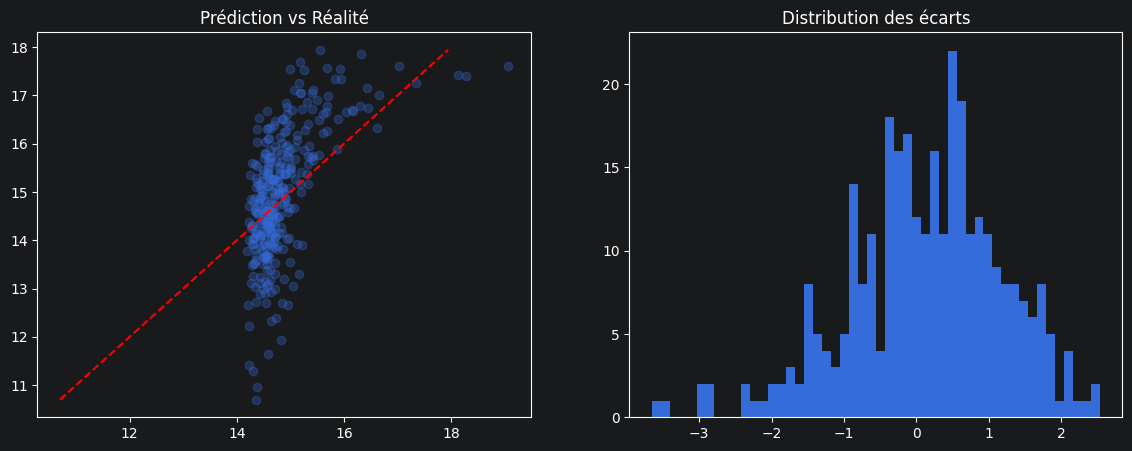

In [146]:
model_lasso = Lasso()
pipeline_lasso_consumption = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', model_lasso)
])
test_model(pipeline_lasso_consumption, data_train_consumption)

### SVR

Scores R² par fold : [0.5788641  0.6521708  0.55857637 0.57075869 0.62525428]
Score moyen (R²) : 0.597 (+/- 0.071)
RMSE moyen (CV) : 1
En moyenne, le modèle se trompe de : 3,614,697 (MAE)
Pénalité des grosses erreurs : 6,999,802 (RMSE)


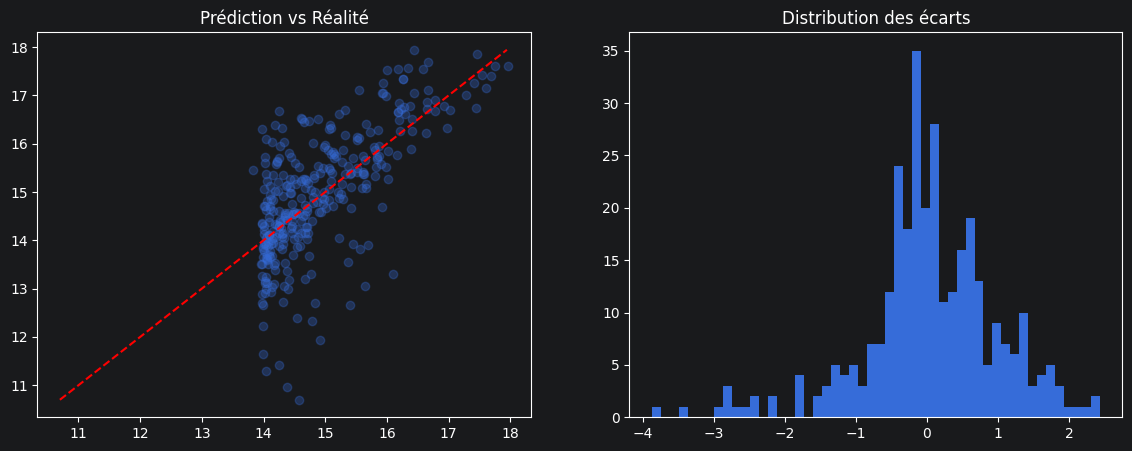

In [147]:
model_svr = SVR()
pipeline_svr_consumption = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', model_svr)
])
test_model(pipeline_svr_consumption, data_train_consumption)

### Analyse des modèles



## Optimisation

In [148]:
def mae_kbtu(y_true, y_pred):
    return mean_absolute_error(np.expm1(y_true), np.expm1(y_pred))

# Optimization du modele de prédiction de la consommation via GridSearch
param_grid = {
    'regressor__n_estimators': [100, 300, 500, 1000],
    'regressor__learning_rate': [0.01, 0.05, 0.1],
    'regressor__max_depth': [2, 3, 4, 5],
    'regressor__subsample': [0.7, 0.8, 1.0],
    'regressor__min_samples_split': [2, 5],
}

scorer_kbtu = make_scorer(mae_kbtu, greater_is_better=False)

grid_search = GridSearchCV(
    estimator=pipeline_xgboost_consumption,
    param_grid=param_grid,
    cv=5,
    scoring=scorer_kbtu,
    n_jobs=-1
)

grid_search.fit(data_train_consumption['X_train'], data_train_consumption['y_train'])

print("\n--- RÉSULTATS DU GRIDSEARCH ---")
print(f"Meilleurs paramètres trouvés : {grid_search.best_params_}")
print(f"Meilleur score MAE : {-grid_search.best_score_:,.0f} kBtu")


--- RÉSULTATS DU GRIDSEARCH ---
Meilleurs paramètres trouvés : {'regressor__learning_rate': 0.1, 'regressor__max_depth': 2, 'regressor__min_samples_split': 2, 'regressor__n_estimators': 500, 'regressor__subsample': 0.7}
Meilleur score MAE : 3,657,508 kBtu


In [149]:
print("\n--- ÉVALUATION DU MEILLEUR MODÈLE OPTIMISÉ ---")
y_pred_log = grid_search.best_estimator_.predict(data_train_consumption['X_test'])

mae = mean_absolute_error(np.expm1(data_train_consumption['y_test']), np.expm1(y_pred_log))
rmse = root_mean_squared_error(np.expm1(data_train_consumption['y_test']), np.expm1(y_pred_log))

print(f"En moyenne, le modèle se trompe de : {mae:,.0f} (MAE)")
print(f"Pénalité des grosses erreurs : {rmse:,.0f} (RMSE)")


--- ÉVALUATION DU MEILLEUR MODÈLE OPTIMISÉ ---
En moyenne, le modèle se trompe de : 3,104,563 (MAE)
Pénalité des grosses erreurs : 6,557,894 (RMSE)


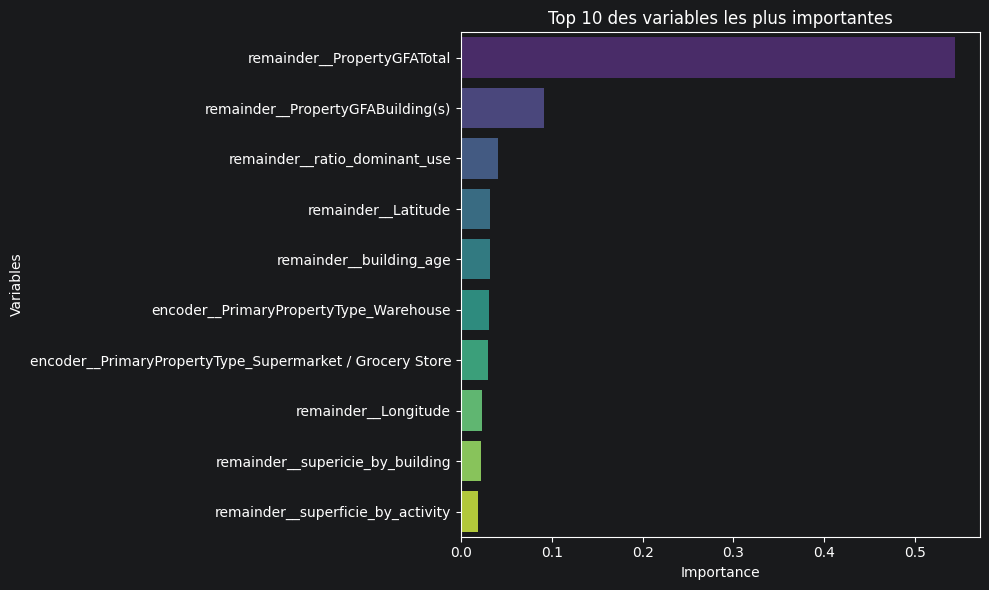

In [150]:
# Affichage des features les plus importantes pour notre modele de prédiction de la consommation
importances = grid_search.best_estimator_['regressor'].feature_importances_

noms_variables = preprocessor.get_feature_names_out()

df_importance = pd.DataFrame({
    'Variable': noms_variables,
    'Importance': importances
})

df_importance = df_importance.sort_values(by='Importance', ascending=False)

top_10 = df_importance.head(10)

plt.figure(figsize=(10, 6))
sns.barplot(
    x='Importance',
    y='Variable',
    data=top_10,
    hue='Variable',
    palette='viridis',
    legend=False
)
plt.title("Top 10 des variables les plus importantes")
plt.xlabel("Importance")
plt.ylabel("Variables")
plt.tight_layout()
plt.show()